## PART 1 - PROJECT OBJECTIVE: The need is to build a regressor which can use these parameters to determine the signal strength or quality [as number]

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import tensorflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")
sns.set(color_codes=True)
%matplotlib inline
from sklearn.model_selection import train_test_split

In [2]:
tensorflow.__version__

NameError: name 'tensorflow' is not defined

In [ ]:
import tensorflow

C:\Users\Ganesan\Anaconda3\lib\site-packages\numpy\_distributor_init.py:32: UserWarning: loaded more than 1 DLL from .libs:
C:\Users\Ganesan\Anaconda3\lib\site-packages\numpy\.libs\libopenblas.IPBC74C7KURV7CB2PKT5Z5FNR3SIBV4J.gfortran-win_amd64.dll
C:\Users\Ganesan\Anaconda3\lib\site-packages\numpy\.libs\libopenblas.WCDJNK7YVMPZQ2ME2ZZHJJRJ3JIKNDB7.gfortran-win_amd64.dll
  stacklevel=1)
C:\Users\Ganesan\Anaconda3\lib\site-packages\tensorflow\python\framework\dtypes.py:526: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
C:\Users\Ganesan\Anaconda3\lib\site-packages\tensorflow\python\framework\dtypes.py:527: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
C:\Users\Ga

In [87]:
#To display comments/observations in 'orange' color and bold
def b(text):
    print("\x1b[33m","***********************************************************************************************************************","\x1b[0m")
    print("\033[1m\x1b[33m","Observations:", "\x1b[0m")
    print("\x1b[33m","***********************************************************************************************************************","\x1b[0m")
    print("\033[1m\x1b[33m",text,"\x1b[0m")
def f(text):
    print("\x1b[33m","***********************************************************************************************************************","\x1b[0m")
    print("\033[1m\x1b[33m","Final Comments:", "\x1b[0m")
    print("\x1b[33m","***********************************************************************************************************************","\x1b[0m")
    print("\033[1m\x1b[33m",text,"\x1b[0m")

### 1. Import data

In [88]:
df_org = pd.read_csv('Part- 1,2&3 - Signal.csv')

In [89]:
df_org.head()

,Parameter 1,Parameter 2,Parameter 3,Parameter 4,Parameter 5,Parameter 6,Parameter 7,Parameter 8,Parameter 9,Parameter 10,Parameter 11,Signal_Strength
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [78]:
df_org.tail()

,Parameter 1,Parameter 2,Parameter 3,Parameter 4,Parameter 5,Parameter 6,Parameter 7,Parameter 8,Parameter 9,Parameter 10,Parameter 11,Signal_Strength
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [79]:
df_org.shape

(1599, 12)

### 2. Data analysis & visualisation
• Perform relevant and detailed statistical analysis on the data.
• Perform relevant and detailed uni, bi and multi variate analysis.

In [8]:
df_org.nunique()

Parameter 1         96
Parameter 2        143
Parameter 3         80
Parameter 4         91
Parameter 5        153
Parameter 6         60
Parameter 7        144
Parameter 8        436
Parameter 9         89
Parameter 10        96
Parameter 11        65
Signal_Strength      6
dtype: int64

In [9]:
df_org.count()

Parameter 1        1599
Parameter 2        1599
Parameter 3        1599
Parameter 4        1599
Parameter 5        1599
Parameter 6        1599
Parameter 7        1599
Parameter 8        1599
Parameter 9        1599
Parameter 10       1599
Parameter 11       1599
Signal_Strength    1599
dtype: int64

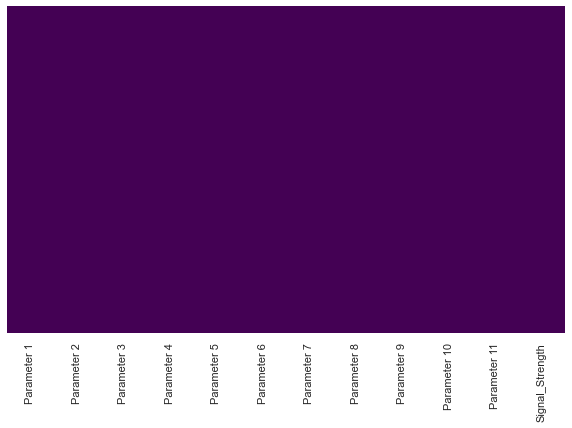

In [65]:
plt.figure(figsize=(10,6))
sns.heatmap(df_org.isnull(), yticklabels=False, cbar=False, cmap='viridis');

In [69]:
#To check if any column contains value 'zero'
df_org.eq(0).any()
b("As per analysis, the columns 'Parameter 3' contains '0' as a value in it")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 As per analysis, the columns 'Parameter 3' contains '0' as a value in it 


In [ ]:
sns.heatmap(df_org., yticklabels=False, cbar=False, cmap='viridis');

In [11]:
def is_null_present(df=df_org):
    is_null = False
    if df.isnull().any().any() == False:
        b("==> There are no null or missing values found in the given dataset.")
    else:
        b("==> There are null values present in the dataset.")
        is_null = True
    return is_null

In [12]:
is_null_present()

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> There are no null or missing values found in the given dataset. 


False

In [13]:
df_org.info()
b("Data type of each attribute is defined as number to feed to NN input layer as expected.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Parameter 1      1599 non-null   float64
 1   Parameter 2      1599 non-null   float64
 2   Parameter 3      1599 non-null   float64
 3   Parameter 4      1599 non-null   float64
 4   Parameter 5      1599 non-null   float64
 5   Parameter 6      1599 non-null   float64
 6   Parameter 7      1599 non-null   float64
 7   Parameter 8      1599 non-null   float64
 8   Parameter 9      1599 non-null   float64
 9   Parameter 10     1599 non-null   float64
 10  Parameter 11     1599 non-null   float64
 11  Signal_Strength  1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
 *********************************************************************************************************************** 
 Observations: 
 *********************************************************

In [14]:
df_org.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Parameter 1,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
Parameter 2,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
Parameter 3,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
Parameter 4,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
Parameter 5,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
Parameter 6,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
Parameter 7,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
Parameter 8,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
Parameter 9,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
Parameter 10,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [15]:
df_org.columns.tolist()

['Parameter 1',
 'Parameter 2',
 'Parameter 3',
 'Parameter 4',
 'Parameter 5',
 'Parameter 6',
 'Parameter 7',
 'Parameter 8',
 'Parameter 9',
 'Parameter 10',
 'Parameter 11',
 'Signal_Strength']

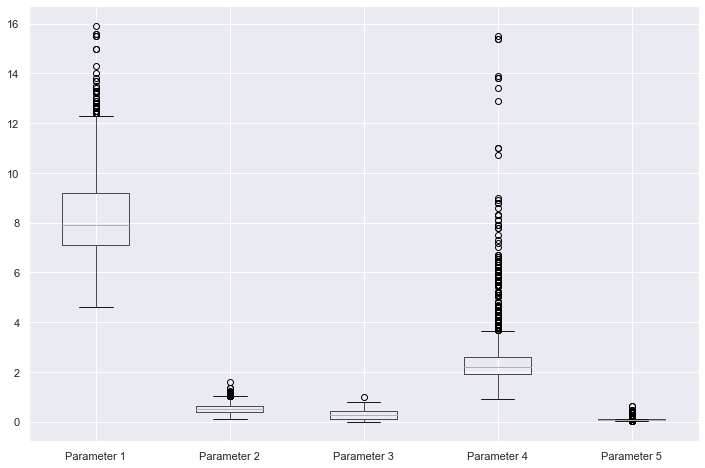

In [57]:
plt.figure(figsize=(12,8))
df_org.boxplot(column=['Parameter 1', 'Parameter 2', 'Parameter 3', 'Parameter 4', 'Parameter 5']);

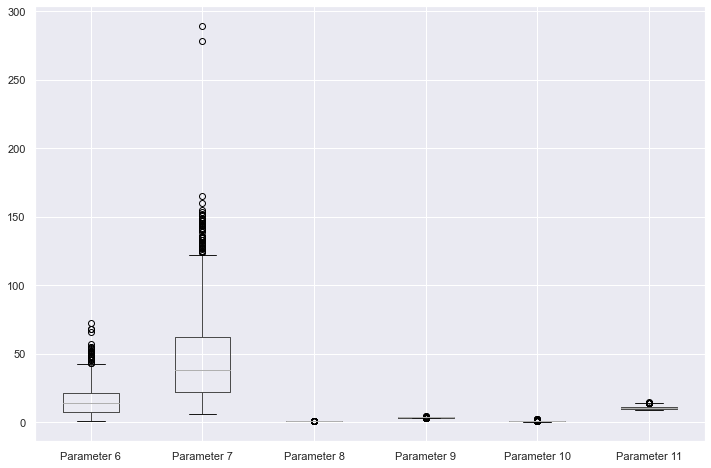

In [58]:
plt.figure(figsize=(12,8))
df_org.boxplot(column=['Parameter 6', 'Parameter 7', 'Parameter 8', 'Parameter 9', 'Parameter 10', 'Parameter 11']);

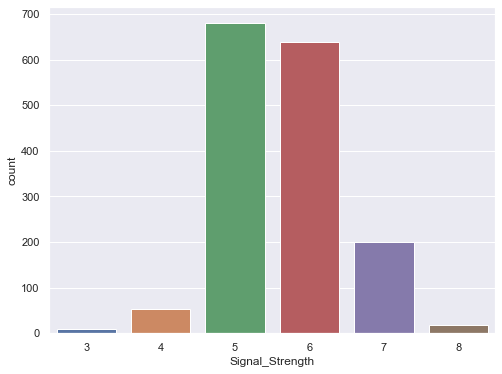

In [59]:
plt.figure(figsize=(8,6))
sns.countplot(df_org.Signal_Strength);

In [60]:
def show_dd(feature_name):
    plt.figure(figsize=(8,5))
    print("Data distribution for column '{0}'".format(feature_name))
    sns.distplot(df_org[feature_name],hist=True, kde=True, rug=True);
    plt.xlabel(feature_name)
    plt.ylabel("frequency")
    plt.title(f"Distribution of '"+feature_name+"'")
    measurements = [round(df_org[feature_name].mean(),2), round(df_org[feature_name].median(),2), round(df_org[feature_name].mode()[0],2)]
    names = ["mean", "median", "mode"]
    colors = ['orange', 'blue', 'green']
    for measurement, name, color in zip(measurements, names, colors):
        plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
    plt.legend();

Data distribution for column 'Parameter 1'
Data distribution for column 'Parameter 2'
Data distribution for column 'Parameter 3'
Data distribution for column 'Parameter 4'
Data distribution for column 'Parameter 5'
Data distribution for column 'Parameter 6'
Data distribution for column 'Parameter 7'
Data distribution for column 'Parameter 8'
Data distribution for column 'Parameter 9'
Data distribution for column 'Parameter 10'
Data distribution for column 'Parameter 11'
Data distribution for column 'Signal_Strength'


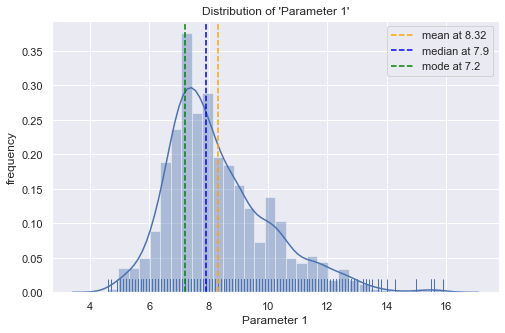

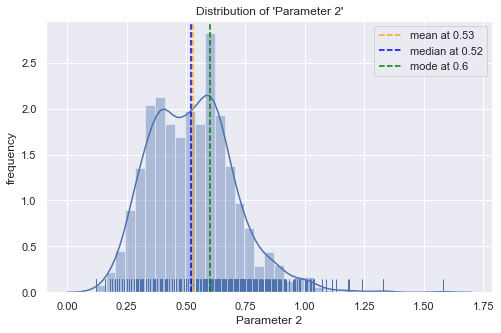

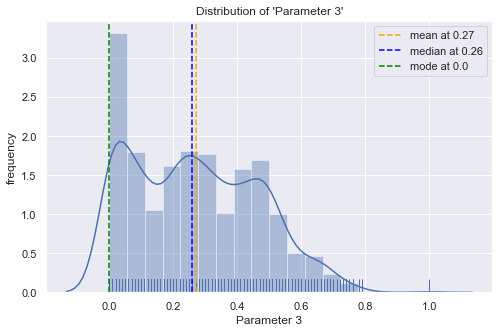

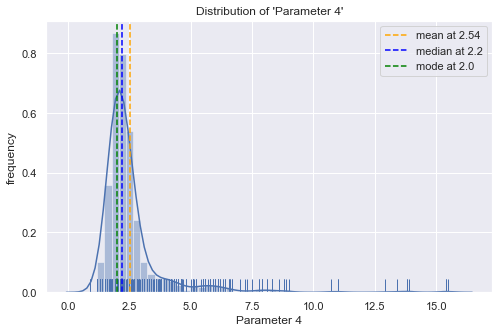

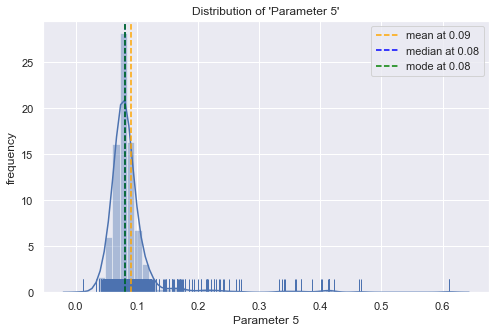

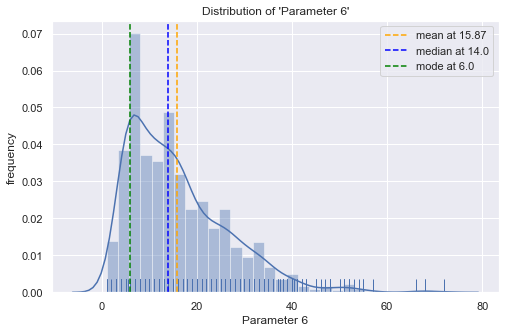

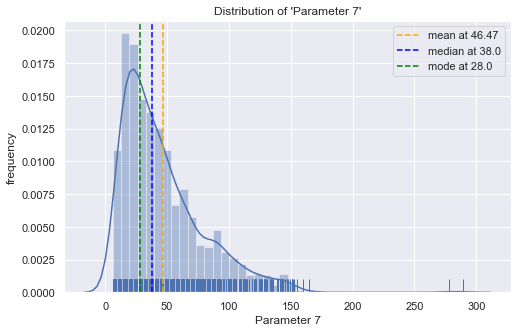

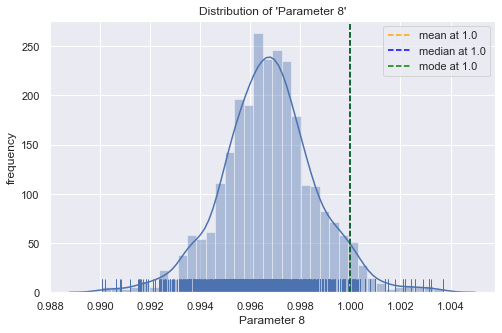

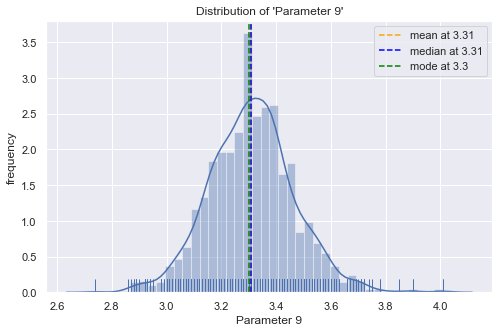

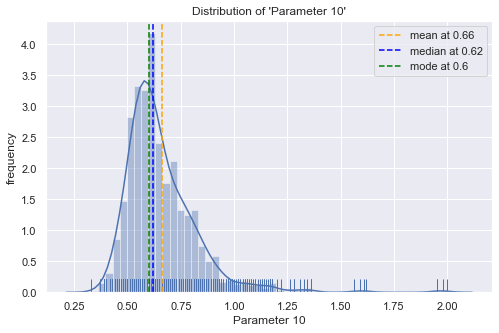

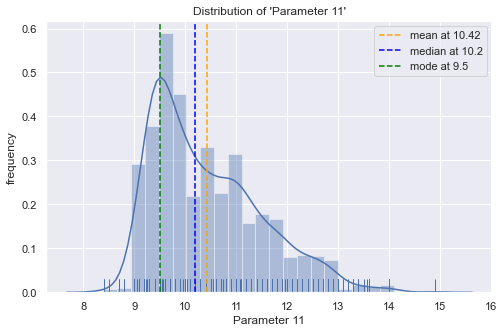

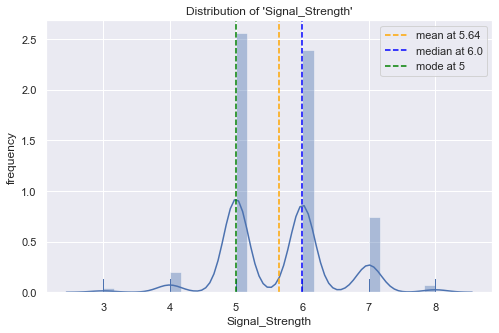

In [61]:
#data distribution analysis for each attribute
feature_list = df_org.columns.tolist()
for feature_name in feature_list:
    show_dd(feature_name)

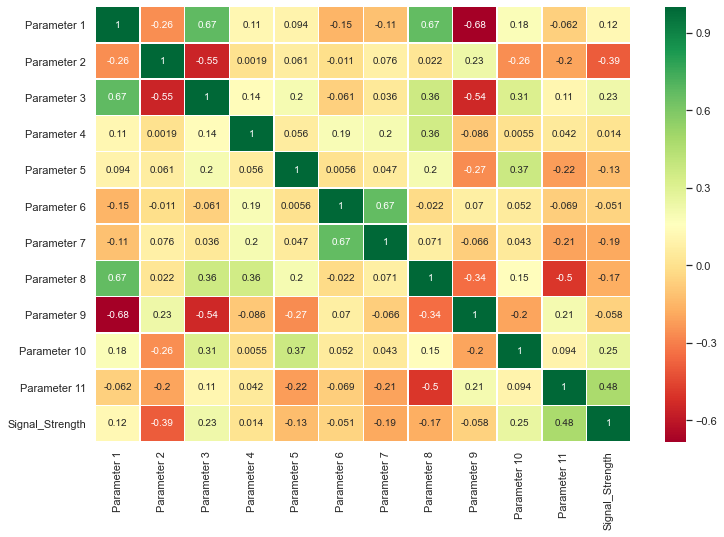

In [62]:
plt.figure(figsize=(12,8))
sns.heatmap(df_org.corr(), annot=True, linewidth=0.5, cmap='RdYlGn');

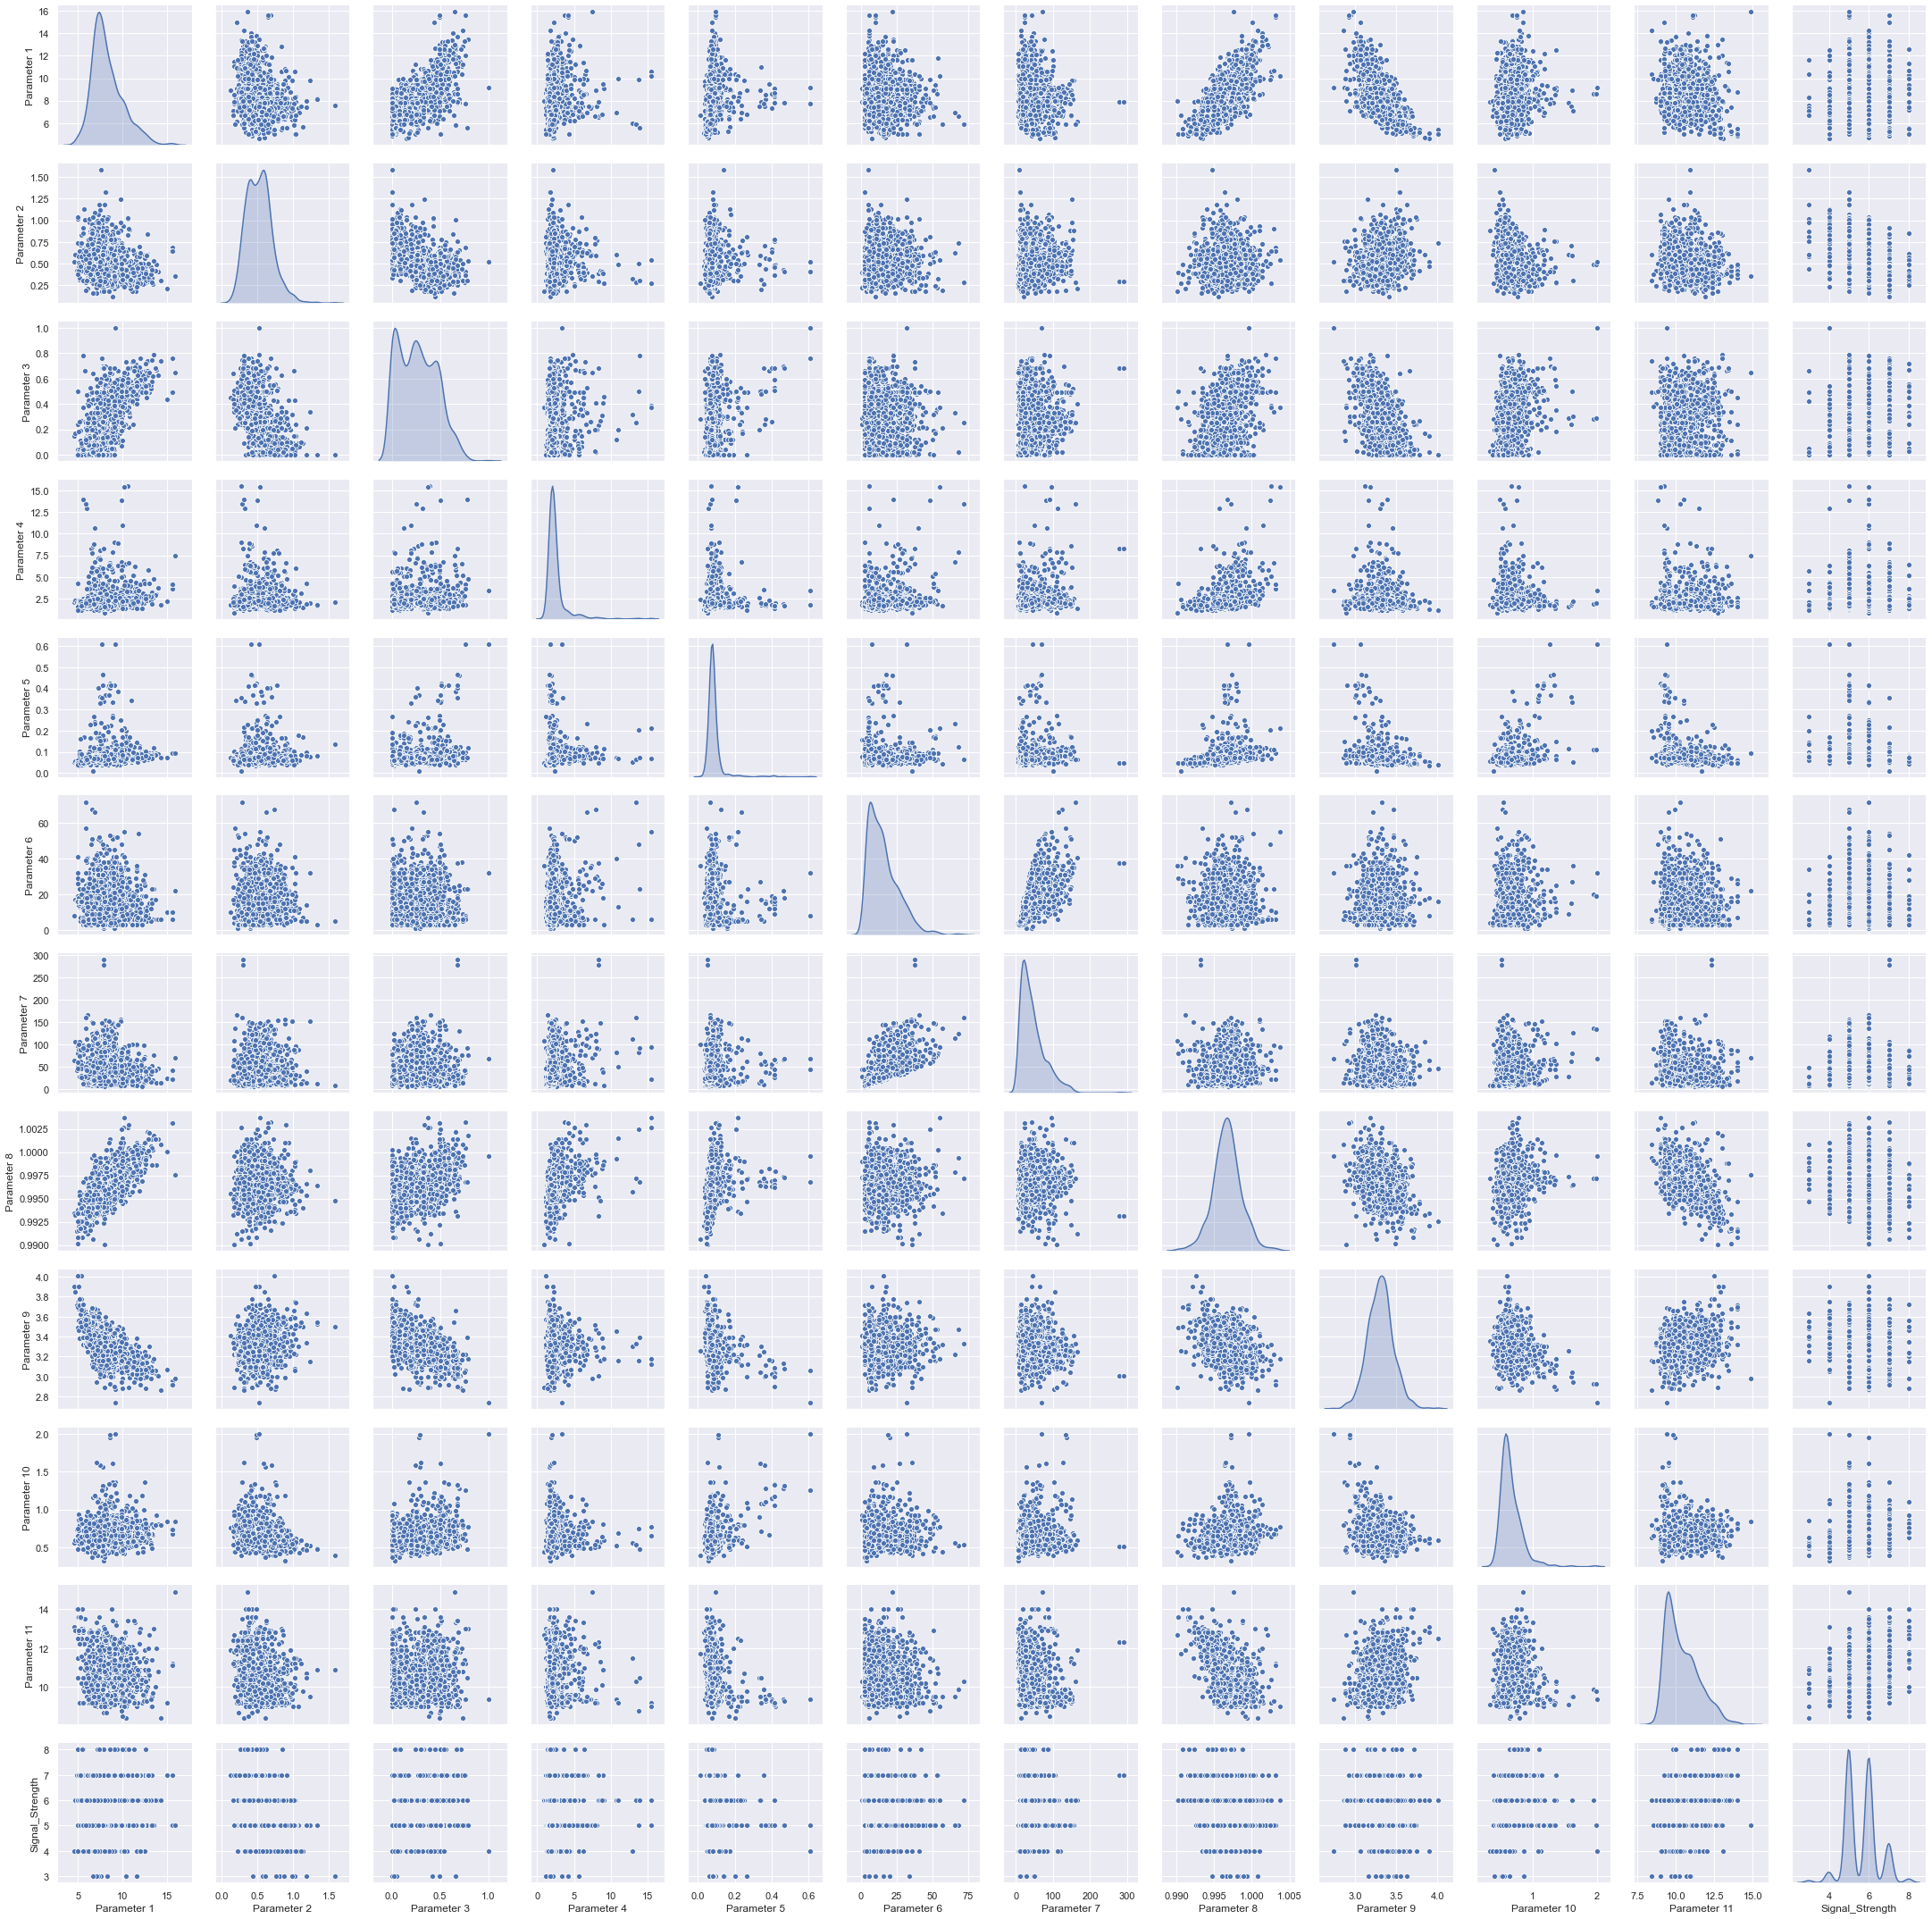

In [30]:
sns.pairplot(df_org, diag_kind='kde');

### 3. Design, train, tune and test a neural network regressor.

In [117]:
X = df_org.iloc[:,0:11]
print(X.columns)
X.shape

Index(['Parameter 1', 'Parameter 2', 'Parameter 3', 'Parameter 4',
       'Parameter 5', 'Parameter 6', 'Parameter 7', 'Parameter 8',
       'Parameter 9', 'Parameter 10', 'Parameter 11'],
      dtype='object')


(1599, 11)

In [118]:
y=df_org.iloc[:,-1:]
y.shape

(1599, 1)

In [119]:
#Split the data into training and test set in the ratio of 70:30 respectively
from sklearn import preprocessing

random_st = 21
stratify_ind = None
#Without scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_st, stratify=stratify_ind)

# Standard Normalization
std_scaler = preprocessing.StandardScaler()
X_std = pd.DataFrame(std_scaler.fit_transform(X))
X_train_std, X_test_std, y_train_std, y_test_std = train_test_split(X_std, y, test_size=0.3, random_state=random_st, stratify=stratify_ind)

In [132]:
def baseline_model():
    reg_model = Sequential(Flatten())
    reg_model.add(Dense(11, input_dim=11, kernel_initializer='normal', activation='relu'))
    reg_model.add(Dense(1, kernel_initializer='normal'))
#     reg_model.compile(loss='mean_squared_error', optimizer='sgd')
    reg_model.compile(loss='mean_squared_error', optimizer='adam')
    return model

In [2]:
from keras.wrappers.scikit_learn import KerasRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

estimator = KerasRegressor(build_fn=baseline_model, epochs=100, batch_size=5, verbose=0)
kfold = KFold(n_splits=10)
results = cross_val_score(estimator, X, y, cv=kfold)
print("Baseline: %.2f (%.2f) MSE" % (results.mean(), results.std()))

ImportError: Keras requires TensorFlow 2.2 or higher. Install TensorFlow via `pip install tensorflow`

In [129]:
pip install keras

Note: you may need to restart the kernel to use updated packages.


In [122]:
# model.compile(optimizer='sgd', loss='mean_squared_error')

Instructions for updating:
Colocations handled automatically by placer.


In [93]:
# model.fit(X_train_std.values, y_train_std.values, epochs=800)

Epoch 1/800
1119/1119 [==============================] - 0s 258us/sample - loss: 18.4226
Epoch 2/800
1119/1119 [==============================] - 0s 60us/sample - loss: 4.8769
Epoch 3/800
1119/1119 [==============================] - 0s 58us/sample - loss: 1.5731
Epoch 4/800
1119/1119 [==============================] - 0s 50us/sample - loss: 0.7459
Epoch 5/800
1119/1119 [==============================] - 0s 45us/sample - loss: 0.5304
Epoch 6/800
1119/1119 [==============================] - 0s 47us/sample - loss: 0.4700
Epoch 7/800
1119/1119 [==============================] - 0s 44us/sample - loss: 0.4504
Epoch 8/800
1119/1119 [==============================] - 0s 53us/sample - loss: 0.4414
Epoch 9/800
1119/1119 [==============================] - 0s 46us/sample - loss: 0.4373
Epoch 10/800
1119/1119 [==============================] - 0s 56us/sample - loss: 0.4345
Epoch 11/800
1119/1119 [==============================] - 0s 55us/sample - loss: 0.4322
Epoch 12/800
1119/1119 [===============

1119/1119 [==============================] - 0s 37us/sample - loss: 0.4270
Epoch 187/800
1119/1119 [==============================] - 0s 37us/sample - loss: 0.4275
Epoch 188/800
1119/1119 [==============================] - 0s 36us/sample - loss: 0.4276
Epoch 189/800
1119/1119 [==============================] - 0s 34us/sample - loss: 0.4267
Epoch 190/800
1119/1119 [==============================] - 0s 35us/sample - loss: 0.4271
Epoch 191/800
1119/1119 [==============================] - 0s 37us/sample - loss: 0.4270
Epoch 192/800
1119/1119 [==============================] - 0s 35us/sample - loss: 0.4274
Epoch 193/800
1119/1119 [==============================] - 0s 35us/sample - loss: 0.4273
Epoch 194/800
1119/1119 [==============================] - 0s 39us/sample - loss: 0.4266
Epoch 195/800
1119/1119 [==============================] - 0s 32us/sample - loss: 0.4271
Epoch 196/800
1119/1119 [==============================] - 0s 34us/sample - loss: 0.4272
Epoch 197/800
1119/1119 [==========

Epoch 278/800
1119/1119 [==============================] - 0s 46us/sample - loss: 0.4272
Epoch 279/800
1119/1119 [==============================] - 0s 47us/sample - loss: 0.4263
Epoch 280/800
1119/1119 [==============================] - 0s 68us/sample - loss: 0.4270
Epoch 281/800
1119/1119 [==============================] - 0s 73us/sample - loss: 0.4271
Epoch 282/800
1119/1119 [==============================] - 0s 40us/sample - loss: 0.4274
Epoch 283/800
1119/1119 [==============================] - 0s 34us/sample - loss: 0.4272
Epoch 284/800
1119/1119 [==============================] - 0s 38us/sample - loss: 0.4270
Epoch 285/800
1119/1119 [==============================] - 0s 34us/sample - loss: 0.4271
Epoch 286/800
1119/1119 [==============================] - 0s 36us/sample - loss: 0.4272
Epoch 287/800
1119/1119 [==============================] - 0s 36us/sample - loss: 0.4266
Epoch 288/800
1119/1119 [==============================] - 0s 35us/sample - loss: 0.4270
Epoch 289/800
1119/11

1119/1119 [==============================] - 0s 40us/sample - loss: 0.4272
Epoch 371/800
1119/1119 [==============================] - 0s 33us/sample - loss: 0.4275
Epoch 372/800
1119/1119 [==============================] - 0s 36us/sample - loss: 0.4273
Epoch 373/800
1119/1119 [==============================] - 0s 39us/sample - loss: 0.4272
Epoch 374/800
1119/1119 [==============================] - 0s 42us/sample - loss: 0.4269
Epoch 375/800
1119/1119 [==============================] - 0s 38us/sample - loss: 0.4271
Epoch 376/800
1119/1119 [==============================] - 0s 35us/sample - loss: 0.4271
Epoch 377/800
1119/1119 [==============================] - 0s 38us/sample - loss: 0.4270
Epoch 378/800
1119/1119 [==============================] - 0s 35us/sample - loss: 0.4273
Epoch 379/800
1119/1119 [==============================] - 0s 37us/sample - loss: 0.4273
Epoch 380/800
1119/1119 [==============================] - 0s 30us/sample - loss: 0.4269
Epoch 381/800
1119/1119 [==========

1119/1119 [==============================] - 0s 35us/sample - loss: 0.4271
Epoch 555/800
1119/1119 [==============================] - 0s 40us/sample - loss: 0.4272
Epoch 556/800
1119/1119 [==============================] - 0s 37us/sample - loss: 0.4274
Epoch 557/800
1119/1119 [==============================] - 0s 36us/sample - loss: 0.4269
Epoch 558/800
1119/1119 [==============================] - 0s 32us/sample - loss: 0.4270
Epoch 559/800
1119/1119 [==============================] - 0s 36us/sample - loss: 0.4271
Epoch 560/800
1119/1119 [==============================] - 0s 34us/sample - loss: 0.4270
Epoch 561/800
1119/1119 [==============================] - 0s 37us/sample - loss: 0.4264
Epoch 562/800
1119/1119 [==============================] - 0s 33us/sample - loss: 0.4266
Epoch 563/800
1119/1119 [==============================] - 0s 36us/sample - loss: 0.4265
Epoch 564/800
1119/1119 [==============================] - 0s 41us/sample - loss: 0.4273
Epoch 565/800
1119/1119 [==========

1119/1119 [==============================] - 0s 38us/sample - loss: 0.4269
Epoch 739/800
1119/1119 [==============================] - 0s 36us/sample - loss: 0.4270
Epoch 740/800
1119/1119 [==============================] - 0s 39us/sample - loss: 0.4271
Epoch 741/800
1119/1119 [==============================] - 0s 35us/sample - loss: 0.4268
Epoch 742/800
1119/1119 [==============================] - 0s 43us/sample - loss: 0.4268
Epoch 743/800
1119/1119 [==============================] - 0s 33us/sample - loss: 0.4264
Epoch 744/800
1119/1119 [==============================] - 0s 37us/sample - loss: 0.4276
Epoch 745/800
1119/1119 [==============================] - 0s 36us/sample - loss: 0.4273
Epoch 746/800
1119/1119 [==============================] - 0s 34us/sample - loss: 0.4276
Epoch 747/800
1119/1119 [==============================] - 0s 31us/sample - loss: 0.4277
Epoch 748/800
1119/1119 [==============================] - 0s 37us/sample - loss: 0.4281
Epoch 749/800
1119/1119 [==========

### 4. Pickle the model for future use.